# 09 · PJM Energy Demand — Probabilistic Forecasting & Backtesting (CQR, walk-forward)

## Part 9 — Probabilistic Forecasting & Backtesting

A grid operator needs more than a single number — they need **how uncertain** the forecast is (to hold
reserve generation) and **proof the model holds up over time**. This part adds three things:

1. **Prediction intervals** via quantile regression — and the discovery that they're **over-confident**,
2. **Conformalized quantile regression (CQR)** — a calibration step that restores honest coverage,
3. A **walk-forward backtest** plus **peak** and **error-by-hour** analysis.

Splits: train (<2017), **calibration (2017)** for conformal, test (2018).

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 130, "display.max_columns", 40)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import forecasting as F
from lightgbm import LGBMRegressor
d = data.clean_primary(); s = d.load_mw
X = F.ml_features(s, d, 24); m = X.dropna().index
tr = m < "2017-01-01"; cal = (m >= "2017-01-01") & (m < "2018-01-01"); te = m >= "2018-01-01"
Xtr, ytr = X.loc[m][tr], s.loc[m][tr]; Xcal, ycal = X.loc[m][cal], s.loc[m][cal]; Xte, yte = X.loc[m][te], s.loc[m][te]
LG = dict(n_estimators=500, learning_rate=0.05, num_leaves=64, verbose=-1, n_jobs=-1)
print("train %d | calib %d | test %d" % (len(ytr), len(ycal), len(yte)))

setup ok | numpy 2.1.3 | pandas 2.3.3


train 131303 | calib 8760 | test 5137


### 1. Quantile intervals — and the over-confidence trap

Train LightGBM with a **quantile** objective at the 10th and 90th percentiles to form an **80%
prediction interval**. Checking the *empirical* coverage on 2018 reveals a problem: the band catches
only **~56%** of actual values, not 80%. Quantile regression on highly autocorrelated load is
**systematically over-confident** — its intervals are too narrow to trust.

In [2]:
lo = LGBMRegressor(objective="quantile", alpha=0.1, **LG).fit(Xtr, ytr)
hi = LGBMRegressor(objective="quantile", alpha=0.9, **LG).fit(Xtr, ytr)
mid = LGBMRegressor(objective="quantile", alpha=0.5, **LG).fit(Xtr, ytr)
ql, qh = lo.predict(Xte), hi.predict(Xte)
raw_cov = ((yte.values >= ql) & (yte.values <= qh)).mean()
print("raw 80%% interval: empirical coverage %.1f%% | mean width %.0f MW  (should be ~80%%)" % (100*raw_cov, (qh-ql).mean()))

raw 80% interval: empirical coverage 55.9% | mean width 3958 MW  (should be ~80%)


### 2. CQR — making the interval honest

**Conformalized Quantile Regression** fixes this. On the **2017 calibration** set we measure the
*conformity score* — how far outside its predicted band each actual value fell — and take its 90th
percentile, `Q`. Widening the test interval by ±`Q` guarantees (distribution-free) the target coverage.
Coverage jumps to **~85%**, at the cost of a wider, honest band — the difference between a forecast you
can plan reserves on and one you can't.

CQR correction Q = 1625 MW -> coverage 85.1% | width 7209 MW


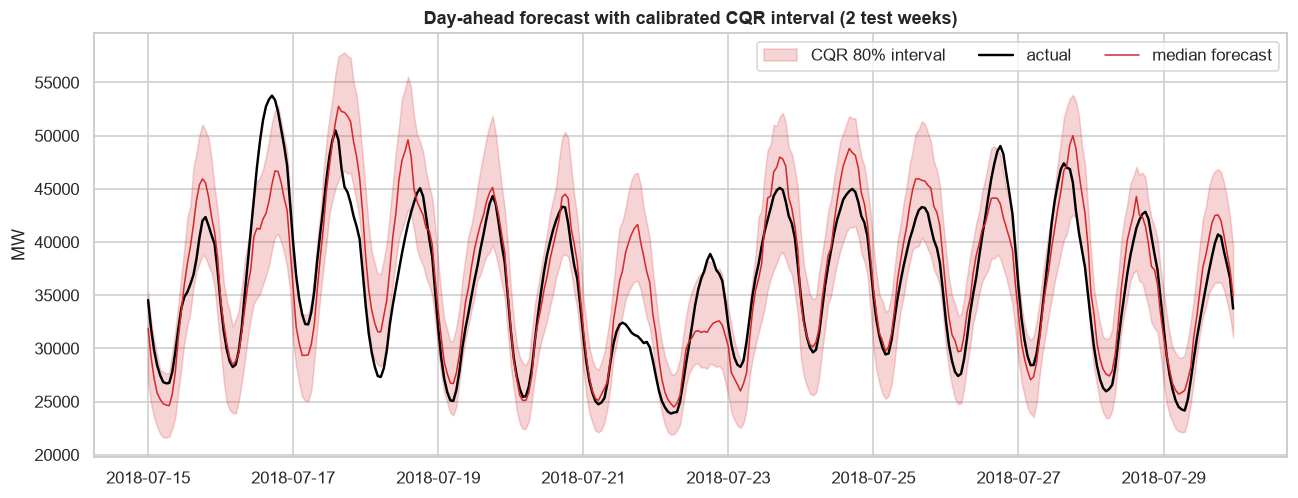

In [3]:
cl, ch = lo.predict(Xcal), hi.predict(Xcal)
E = np.maximum(cl - ycal.values, ycal.values - ch)        # conformity scores
Q = np.quantile(E, 0.9)
cqr_cov = ((yte.values >= ql - Q) & (yte.values <= qh + Q)).mean()
print("CQR correction Q = %.0f MW -> coverage %.1f%% | width %.0f MW" % (Q, 100*cqr_cov, (qh+Q-(ql-Q)).mean()))
win = slice("2018-07-15", "2018-07-29")
idx = yte.loc[win].index; sel = yte.index.isin(idx)
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(idx, (ql-Q)[sel], (qh+Q)[sel], color="tab:red", alpha=.2, label="CQR 80% interval")
ax.plot(idx, yte.loc[win].values, color="black", lw=1.6, label="actual")
ax.plot(idx, mid.predict(Xte)[sel], color="tab:red", lw=1, label="median forecast")
ax.set_ylabel("MW"); ax.set_title("Day-ahead forecast with calibrated CQR interval (2 test weeks)"); ax.legend(ncol=3)
eda.savefig(fig, "p9_intervals.png"); plt.show()

### 3. Walk-forward backtest — does it hold up all year?

A single split can flatter a model. We **walk forward** through 2018: for each month, retrain on *all*
prior data and forecast that month one day ahead. The per-month MAPE stays in a tight **~4–8%** band —
worse in volatile **summer** (June–August), best in mild spring — confirming the model is **stable**,
not a one-window fluke.

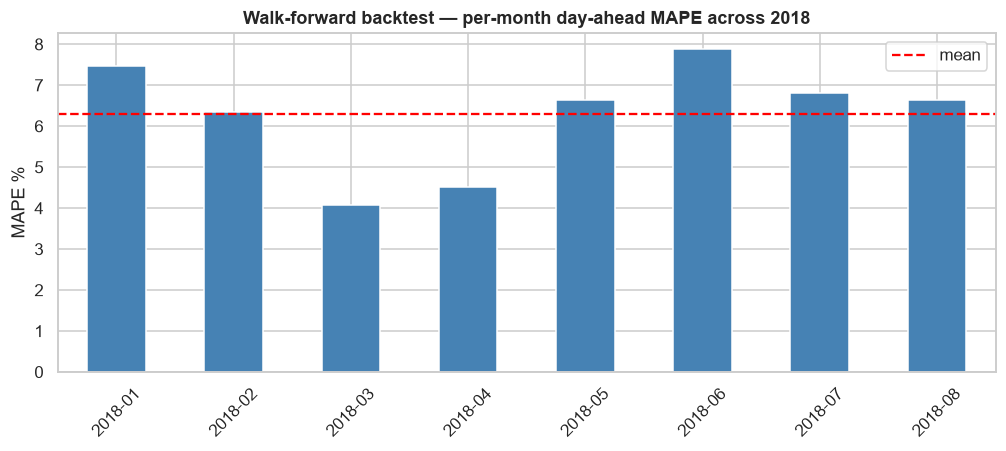

walk-forward MAPE: mean 6.29% | range 4.06–7.88%


In [4]:
months = pd.period_range("2018-01", "2018-08", freq="M")
bt = {}
for p in months:
    cutoff = p.to_timestamp()
    tr_i = m < cutoff; te_i = (m >= cutoff) & (m < (p+1).to_timestamp())
    if te_i.sum() == 0: continue
    mdl = LGBMRegressor(**LG, objective="regression").fit(X.loc[m][tr_i], s.loc[m][tr_i])
    yp = mdl.predict(X.loc[m][te_i]); yt = s.loc[m][te_i].values
    bt[str(p)] = np.mean(np.abs((yt - yp)/yt))*100
fig, ax = plt.subplots(figsize=(11, 4))
pd.Series(bt).plot.bar(ax=ax, color="steelblue", rot=45); ax.set_ylabel("MAPE %"); ax.axhline(np.mean(list(bt.values())), color="red", ls="--", label="mean")
ax.set_title("Walk-forward backtest — per-month day-ahead MAPE across 2018"); ax.legend()
eda.savefig(fig, "p9_backtest.png"); plt.show()
print("walk-forward MAPE: mean %.2f%% | range %.2f–%.2f%%" % (np.mean(list(bt.values())), min(bt.values()), max(bt.values())))

### 4. Where the error lives — peaks & hours

Two operationally crucial cuts. **Peak forecasting**: how well we predict each day's *maximum* (what
sizes reserves) — comparable to the overall error here. **Error by hour × season**: the largest errors
concentrate in the **late-afternoon peak hours (16–18)** and in **summer** — precisely when the grid is
most stressed, so the residual risk is where it hurts most.

daily-peak forecast MAPE: 6.20% | overall 6.34%


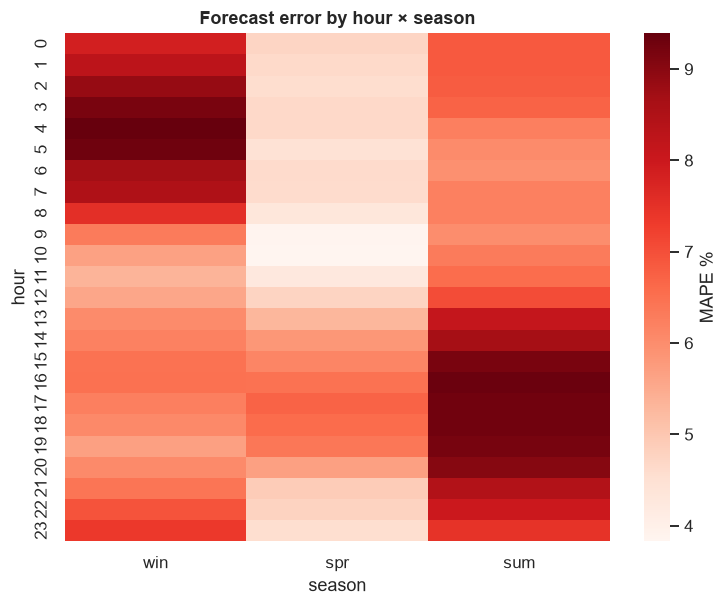

worst hours: {17: 7.3, 16: 7.3, 18: 7.2}


In [5]:
yp_pt = LGBMRegressor(**LG, objective="regression").fit(Xtr, ytr).predict(Xte)
err = pd.Series(np.abs((yte.values - yp_pt)/yte.values)*100, index=yte.index)
dmax_a = yte.groupby(yte.index.normalize()).max(); dmax_p = pd.Series(yp_pt, index=yte.index).groupby(yte.index.normalize()).max()
peak_mape = np.mean(np.abs((dmax_a - dmax_p)/dmax_a))*100
print("daily-peak forecast MAPE: %.2f%% | overall %.2f%%" % (peak_mape, err.mean()))
seas = pd.Series(yte.index.month % 12 // 3, index=yte.index).map({0:"win",1:"spr",2:"sum",3:"fall"})
hm = err.groupby([err.index.hour, seas]).mean().unstack()
order = [c for c in ["win","spr","sum","fall"] if c in hm.columns]    # 2018 test ends in Aug -> no fall
fig, ax = plt.subplots(figsize=(8, 6)); sns.heatmap(hm[order], cmap="Reds", ax=ax, cbar_kws={"label":"MAPE %"})
ax.set_xlabel("season"); ax.set_ylabel("hour"); ax.set_title("Forecast error by hour × season")
eda.savefig(fig, "p9_error_heatmap.png"); plt.show()
print("worst hours:", err.groupby(err.index.hour).mean().nlargest(3).round(1).to_dict())

### Takeaways

- Raw **quantile intervals are over-confident** (56% coverage for a nominal 80%) — a real trap on
  autocorrelated load.
- **CQR** restores honest coverage (~85%) using a calibration set — distribution-free, and essential
  for planning reserves.
- A **walk-forward backtest** confirms stability: per-month day-ahead MAPE stays ~4–8% all year
  (worse in summer).
- Errors concentrate at the **afternoon peak hours and in summer** — the residual risk sits exactly
  where the grid is most stressed.

**Next — Part 10 (Load profiling):** cluster days into characteristic **load-shape regimes** (workday
vs weekend vs holiday vs heat-wave) — a different, unsupervised lens on the same series.